In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv("../datas/final_heart_data.csv")

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,systolic,diastolic,Heart Attack Risk
0,0,67,1,208,72,0,0,1,0,0,...,9,6.615001,261404,31.251233,286,0,6,158,88,0
1,1,21,1,389,98,1,1,1,1,1,...,1,4.963459,285768,27.194973,235,1,7,165,93,0
2,2,21,0,324,72,1,0,0,0,0,...,9,9.463426,235282,28.176571,587,4,4,174,99,0
3,3,84,1,383,73,1,1,1,0,1,...,9,7.648981,125640,36.464704,378,3,4,163,100,0
4,4,66,1,318,93,1,1,1,1,0,...,6,1.514821,160555,21.809144,231,1,5,91,88,0


In [5]:
y=df.pop('Heart Attack Risk')

In [6]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df,y,test_size=0.2)

In [8]:
dc.fit(x_train,y_train)

DecisionTreeClassifier()

In [9]:
pred=dc.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,pred)

In [11]:
acc*100

53.56531660011409

<Axes: >

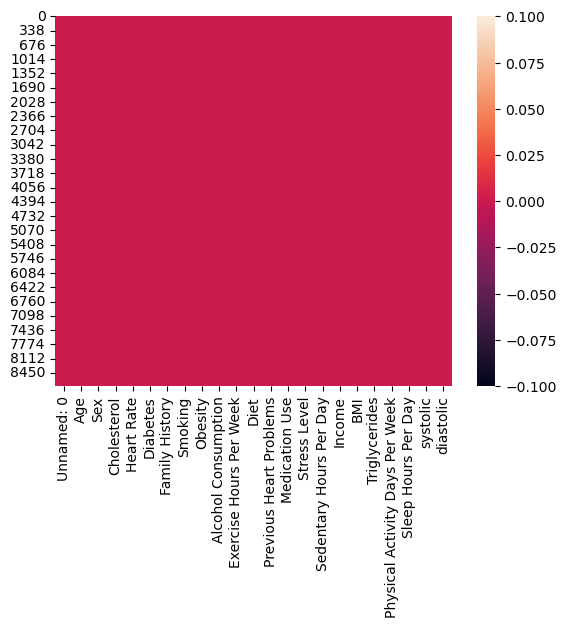

In [12]:
sns.heatmap(df.isnull())

<Axes: >

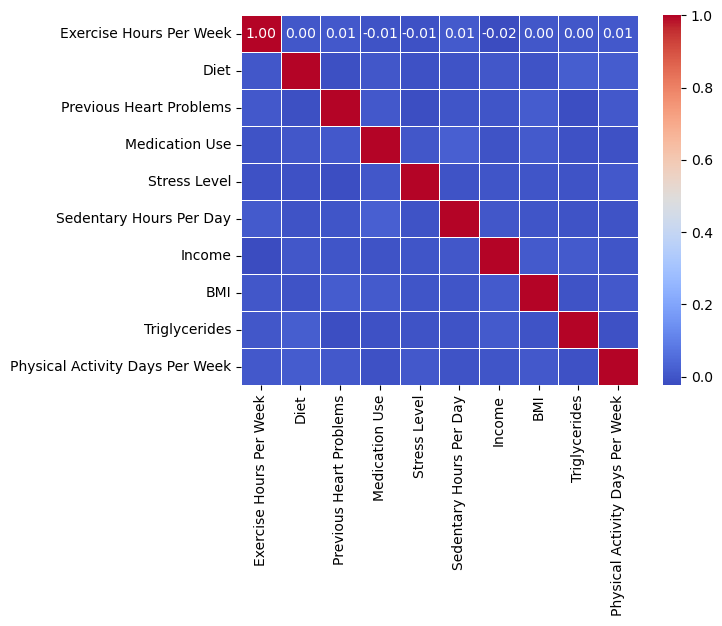

In [13]:
sns.heatmap(df.iloc[:,10:20].corr(),annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [14]:
df.head()

,Unnamed: 0,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,systolic,diastolic
0,0,67,1,208,72,0,0,1,0,0,...,0,9,6.615001,261404,31.251233,286,0,6,158,88
1,1,21,1,389,98,1,1,1,1,1,...,0,1,4.963459,285768,27.194973,235,1,7,165,93
2,2,21,0,324,72,1,0,0,0,0,...,1,9,9.463426,235282,28.176571,587,4,4,174,99
3,3,84,1,383,73,1,1,1,0,1,...,0,9,7.648981,125640,36.464704,378,3,4,163,100
4,4,66,1,318,93,1,1,1,1,0,...,0,6,1.514821,160555,21.809144,231,1,5,91,88


In [15]:
df.pop('Unnamed: 0')


0          0
1          1
2          2
3          3
4          4
        ... 
8758    8758
8759    8759
8760    8760
8761    8761
8762    8762
Name: Unnamed: 0, Length: 8763, dtype: int64

In [16]:
df.to_csv("../datas/final_heart_datas.csv")

In [17]:
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,systolic,diastolic
0,67,1,208,72,0,0,1,0,0,4.168189,...,0,9,6.615001,261404,31.251233,286,0,6,158,88
1,21,1,389,98,1,1,1,1,1,1.813242,...,0,1,4.963459,285768,27.194973,235,1,7,165,93
2,21,0,324,72,1,0,0,0,0,2.078353,...,1,9,9.463426,235282,28.176571,587,4,4,174,99
3,84,1,383,73,1,1,1,0,1,9.828130,...,0,9,7.648981,125640,36.464704,378,3,4,163,100
4,66,1,318,93,1,1,1,1,0,5.804299,...,0,6,1.514821,160555,21.809144,231,1,5,91,88


In [18]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'systolic',
       'diastolic'],
      dtype='object')

In [19]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
y

0       0
1       0
2       0
3       0
4       0
       ..
8758    0
8759    0
8760    1
8761    0
8762    1
Name: Heart Attack Risk, Length: 8763, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df,y,test_size=0.20)

In [21]:
from mlxtend.feature_selection import SequentialFeatureSelector
sfs=SequentialFeatureSelector(LR,verbose=True,forward=True,k_features=(1,x_train.shape[1]),scoring='accuracy')

In [22]:
sfs.fit(x_train,y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    1.3s finished
Features: 1/22[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  21 out of  21 | elapsed:    5.0s finished
Features: 2/22[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
c:\Users\ravik\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    6.4s finished
Featu

SequentialFeatureSelector(estimator=LogisticRegression(), k_features=(1, 22),
                          scoring='accuracy', verbose=True)

In [ ]:
sfs.k_feature_names_

('Unnamed: 0',)

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5)

In [ ]:
from sklearn.feature_selection import RFECV
refcv=RFECV(estimator=LR,cv=cv,scoring='accuracy',n_jobs=-1,step=1)

In [ ]:
refcv.fit(x_train,y_train)

KeyboardInterrupt: 

In [ ]:
print(refcv.get_support())

[False False False False  True False False False False False False False
 False False False False False False False False False False]


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Initialize RFECV
estimator = LogisticRegression(max_iter=1000)
selector = RFECV(estimator, step=1, cv=5, scoring='accuracy')
selector.fit(df, y)

# Get selected features
rfecv_results = pd.DataFrame({'Feature': df.columns,
                             'Rank': selector.ranking_})
print("\nRFECV Results:")
print(rfecv_results.sort_values('Rank').head(10))

c:\Users\ravik\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ravik\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_


RFECV Results:
                            Feature  Rank
4                          Diabetes     1
8               Alcohol Consumption     2
7                           Obesity     3
6                           Smoking     4
1                               Sex     5
19              Sleep Hours Per Day     6
10                             Diet     7
12                   Medication Use     8
5                    Family History     9
18  Physical Activity Days Per Week    10


In [ ]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'systolic',
       'diastolic'],
      dtype='object')

age
sex
chloestrol
heart rate
Diabets
smoking
Obesity
previous heart problem
BMI
systolic
Diastolic

In [23]:
newdf=df.iloc[:,[0,1,2,3,4,6,7,11,16,20,21]]

In [24]:
newdf.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Smoking',
       'Obesity', 'Previous Heart Problems', 'BMI', 'systolic', 'diastolic'],
      dtype='object')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
LR=LogisticRegression()
RF=RandomForestClassifier()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(newdf,y,test_size=0.2)

In [ ]:
LR.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
pred=LR.predict(x_test)
acc=accuracy_score(y_test,pred)
acc*100

c:\Users\ravik\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


63.49115801483172

In [ ]:
RF.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
pred=RF.predict(x_test)
acc=accuracy_score(y_test,pred)
acc*100

62.86366229321164

In [ ]:
RF.feature_importances_

array([0.14531555, 0.01826298, 0.16329292, 0.14409895, 0.02030379,
       0.00832374, 0.02130381, 0.02359004, 0.17679078, 0.14592077,
       0.13279667])

In [ ]:
df

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,systolic,diastolic
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,0,9,6.615001,261404,31.251233,286,0,6,158,88
1,21,1,389,98,1,1,1,1,1,1.813242,2,1,0,1,4.963459,285768,27.194973,235,1,7,165,93
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,1,9,9.463426,235282,28.176571,587,4,4,174,99
3,84,1,383,73,1,1,1,0,1,9.828130,0,1,0,9,7.648981,125640,36.464704,378,3,4,163,100
4,66,1,318,93,1,1,1,1,0,5.804299,2,1,0,6,1.514821,160555,21.809144,231,1,5,91,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,1,1,1,8,10.806373,235420,19.655895,67,7,7,94,76
8759,28,0,120,73,1,0,0,1,0,16.558426,1,0,0,8,3.833038,217881,23.993866,617,4,9,157,102
8760,47,1,250,105,0,1,1,1,1,3.148438,0,1,0,5,2.375214,36998,35.406146,527,4,4,161,75
8761,36,1,178,60,1,0,1,0,0,3.789950,2,1,1,5,0.029104,209943,27.294020,114,2,8,119,67


In [ ]:
newdf.describe()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Smoking,Obesity,Previous Heart Problems,BMI,systolic,diastolic
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,0.697364,259.877211,75.021682,0.652288,0.896839,0.501426,0.495835,28.891446,135.075659,85.156111
std,21.249509,0.459425,80.863276,20.550948,0.476271,0.304186,0.500026,0.500011,6.319181,26.349976,14.676565
min,18.000000,0.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,18.002337,90.000000,60.000000
25%,35.000000,0.000000,192.000000,57.000000,0.000000,1.000000,0.000000,0.000000,23.422985,112.000000,72.000000
50%,54.000000,1.000000,259.000000,75.000000,1.000000,1.000000,1.000000,0.000000,28.768999,135.000000,85.000000
75%,72.000000,1.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,34.324594,158.000000,98.000000
max,90.000000,1.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,39.997211,180.000000,110.000000


In [ ]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(random_state=None, shuffle=False,n_splits=5)
LR=LogisticRegression(cv)

In [ ]:
import joblib
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define Stratified K-Fold
cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

best_model = None
best_accuracy = 0
i=0
# Loop through each fold
for train_idx, val_idx in cv.split(x_train, y_train):
    # ✅ Use `.iloc[]` to index DataFrame correctly
    X_train_fold, X_val_fold = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    # Train Logistic Regression
    model = SVC()
    model.fit(X_train_fold, y_train_fold)

    # Validate on fold
    y_pred = model.predict(X_val_fold)
    acc = accuracy_score(y_val_fold, y_pred)

    # Check if this model is the best
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

# Save the best model
# joblib.dump(best_model, "best_model.pkl")

print(f"Best Model Saved with Accuracy: {best_accuracy * 100:.2f}%")


Best Model Saved with Accuracy: 64.45%


In [ ]:
print(f"Best Model Saved with Accuracy: {best_accuracy * 100:.2f}%")


Best Model Saved with Accuracy: 64.41%


In [25]:
newdf.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Smoking,Obesity,Previous Heart Problems,BMI,systolic,diastolic
0,67,1,208,72,0,1,0,0,31.251233,158,88
1,21,1,389,98,1,1,1,1,27.194973,165,93
2,21,0,324,72,1,0,0,1,28.176571,174,99
3,84,1,383,73,1,1,0,1,36.464704,163,100
4,66,1,318,93,1,1,1,1,21.809144,91,88


In [26]:
y

0       0
1       0
2       0
3       0
4       0
       ..
8758    0
8759    0
8760    1
8761    0
8762    1
Name: Heart Attack Risk, Length: 8763, dtype: int64

In [27]:
from sklearn.utils.class_weight import compute_class_weight
classwei=compute_class_weight(y=y,class_weight='balanced',classes=np.unique(y))

In [28]:
classweidict={0:classwei[0],1:classwei[1]*1.5}

In [29]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(class_weight=classweidict)

In [30]:
LR

LogisticRegression(class_weight={0: 0.7790718349928877, 1: 2.093740044600191})

In [52]:
from sklearn.model_selection import train_test_split
xtr,xte,ytr,yte=train_test_split(newdf,y,test_size=0.20)

In [60]:
newdf['Heart Attack Risk']=y

C:\Users\ravik\AppData\Local\Temp\ipykernel_22200\69223029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newdf['Heart Attack Risk']=y


In [61]:
newdf

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Smoking,Obesity,Previous Heart Problems,BMI,systolic,diastolic,Heart Attack Risk
0,67,1,208,72,0,1,0,0,31.251233,158,88,0
1,21,1,389,98,1,1,1,1,27.194973,165,93,0
2,21,0,324,72,1,0,0,1,28.176571,174,99,0
3,84,1,383,73,1,1,0,1,36.464704,163,100,0
4,66,1,318,93,1,1,1,1,21.809144,91,88,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,0,1,19.655895,94,76,0
8759,28,0,120,73,1,0,1,0,23.993866,157,102,0
8760,47,1,250,105,0,1,1,1,35.406146,161,75,1
8761,36,1,178,60,1,1,0,1,27.294020,119,67,0


In [62]:
newdf.to_csv("../datas/newdf.csv")

In [ ]:
dataset=pd.read_csv("../datas/newdf.csv")

In [64]:
dataset.head()

,Unnamed: 0,Age,Sex,Cholesterol,Heart Rate,Diabetes,Smoking,Obesity,Previous Heart Problems,BMI,systolic,diastolic,Heart Attack Risk
0,0,67,1,208,72,0,1,0,0,31.251233,158,88,0
1,1,21,1,389,98,1,1,1,1,27.194973,165,93,0
2,2,21,0,324,72,1,0,0,1,28.176571,174,99,0
3,3,84,1,383,73,1,1,0,1,36.464704,163,100,0
4,4,66,1,318,93,1,1,1,1,21.809144,91,88,0


In [ ]:
y=